# Machine Learning para NLP

En este notebook se aplican técnicas de Machine Learning clásico para tareas de clasificación de texto.

Siguiendo la lógica del pipeline de NLP, partimos de texto sin estructurar que debe ser transformado en representaciones numéricas (features) antes de ser utilizado por modelos de Machine Learning.

En este caso utilizamos **TF-IDF**, una técnica que pondera la importancia de cada palabra en función de su frecuencia en el documento y en el corpus.

Posteriormente, se entrenan distintos modelos de clasificación para predecir la categoría de cada texto.

In [17]:
import pandas as pd

import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score, classification_report

In [19]:
def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(title)
    plt.show()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/data/dataframe_limpio.csv')
df.head(6)

,timestamp,person,message,message_length_words,message_length_chars
0,2022-07-10 20:14:08,Paula,Me estoy agobiando con los grupos,6,33
1,2022-07-10 20:14:12,Paula,Asiq hablamos por aqui,4,22
2,2022-07-10 20:14:12,Carmen,Coño,1,4
3,2022-07-10 20:14:14,Carmen,Gracias,1,7
4,2022-07-10 20:14:15,Carmen,Jajjjajajj,1,10
5,2022-07-10 20:14:38,Carmen,A ver,2,5


In [5]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)  # quitar números
    texto = re.sub(r'[^\w\s]', '', texto)  # quitar símbolos/emojis
    return texto

df["message"] = df["message"].apply(limpiar_texto)

In [6]:
# Nos quedamos con lo importante
df = df[['message', 'person']].dropna()

## Vectorización del texto

Los modelos de Machine Learning no trabajan directamente con texto, sino con vectores numéricos.

Para ello recuperamos el TF-IDF hecho en el notebook 2. Discriminative Models

In [9]:
# cargar todo
tfidf_vectorizer = pickle.load(open("/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/tfidf.pkl","rb"))
le = pickle.load(open("/content/drive/MyDrive/TRABAJO_NO_ESTRUCTURADOS/TRABAJO_NO_ESTRUCTURADOS/models/le.pkl","rb"))

# reconstruir
X = tfidf_vectorizer.transform(df['message'])
y = le.transform(df['person'])

Dividimos el dataset en entrenamiento y test para evaluar correctamente el modelo.

In [13]:
# TRAIN / TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modelos de clasificación

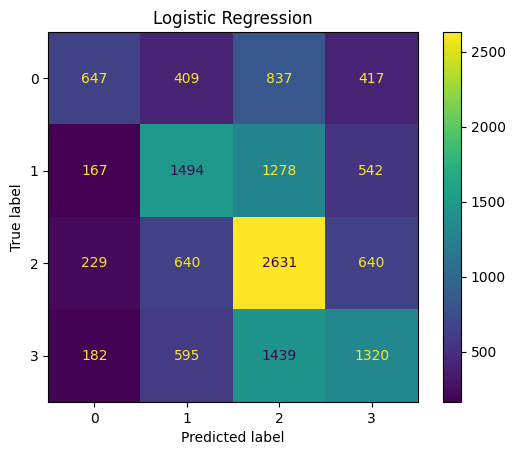

              precision    recall  f1-score   support

           0       0.53      0.28      0.37      2310
           1       0.48      0.43      0.45      3481
           2       0.43      0.64      0.51      4140
           3       0.45      0.37      0.41      3536

    accuracy                           0.45     13467
   macro avg       0.47      0.43      0.43     13467
weighted avg       0.46      0.45      0.44     13467



In [20]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

plot_confusion(y_test, y_pred_lr, "Logistic Regression")
print(classification_report(y_test, y_pred_lr))

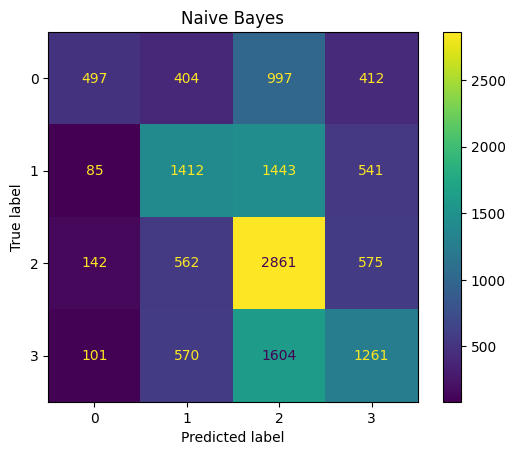

              precision    recall  f1-score   support

           0       0.60      0.22      0.32      2310
           1       0.48      0.41      0.44      3481
           2       0.41      0.69      0.52      4140
           3       0.45      0.36      0.40      3536

    accuracy                           0.45     13467
   macro avg       0.49      0.42      0.42     13467
weighted avg       0.47      0.45      0.43     13467



In [21]:
# Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

plot_confusion(y_test, y_pred_nb, "Naive Bayes")
print(classification_report(y_test, y_pred_nb))

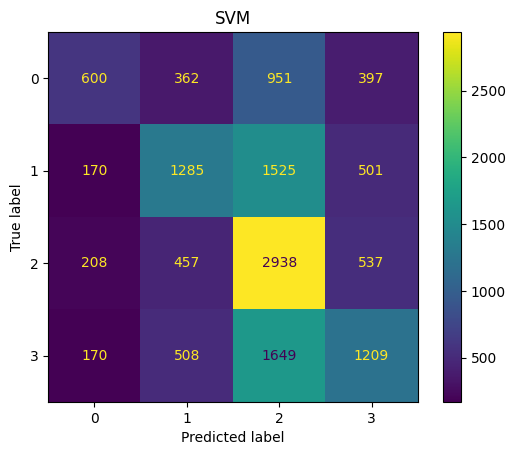

              precision    recall  f1-score   support

           0       0.52      0.26      0.35      2310
           1       0.49      0.37      0.42      3481
           2       0.42      0.71      0.52      4140
           3       0.46      0.34      0.39      3536

    accuracy                           0.45     13467
   macro avg       0.47      0.42      0.42     13467
weighted avg       0.46      0.45      0.43     13467



In [22]:
# SVM
model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)

plot_confusion(y_test, y_pred_svm, "SVM")
print(classification_report(y_test, y_pred_svm))

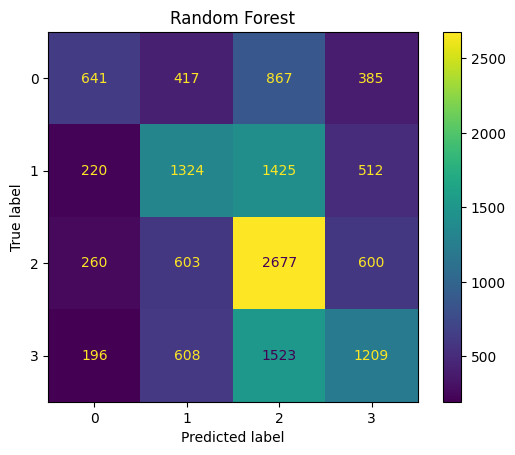

              precision    recall  f1-score   support

           0       0.49      0.28      0.35      2310
           1       0.45      0.38      0.41      3481
           2       0.41      0.65      0.50      4140
           3       0.45      0.34      0.39      3536

    accuracy                           0.43     13467
   macro avg       0.45      0.41      0.41     13467
weighted avg       0.44      0.43      0.42     13467



In [23]:
# Random Forest
model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

plot_confusion(y_test, y_pred_rf, "Random Forest")
print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


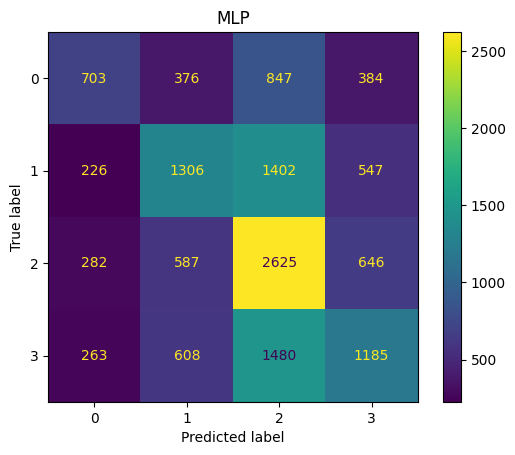

              precision    recall  f1-score   support

           0       0.48      0.30      0.37      2310
           1       0.45      0.38      0.41      3481
           2       0.41      0.63      0.50      4140
           3       0.43      0.34      0.38      3536

    accuracy                           0.43     13467
   macro avg       0.44      0.41      0.41     13467
weighted avg       0.44      0.43      0.42     13467



In [27]:
# Red Neuronal (MLP)
model_nn = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
model_nn.fit(X_train, y_train)
y_pred_nn = model_nn.predict(X_test)

plot_confusion(y_test, y_pred_nn, "MLP")
print(classification_report(y_test, y_pred_nn))

## Comparación de modelos

In [28]:
from sklearn.metrics import accuracy_score

results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "MLP": accuracy_score(y_test, y_pred_nn)
}

results

{'Logistic Regression': 0.4523650404692953,
 'SVM': 0.4479097052053167,
 'Random Forest': 0.4344694438256479,
 'Naive Bayes': 0.4478354496175837,
 'MLP': 0.4320932650181926}

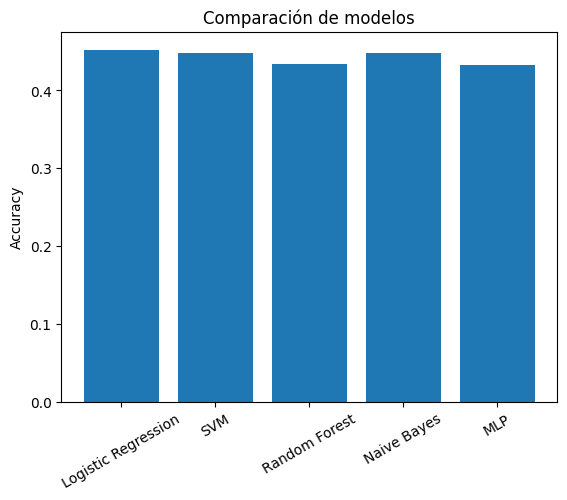

In [29]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Comparación de modelos")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

Aunque los resultados obtenidos en la clasificación de las cuatro categorías no parecen ser muy altos, es importante tener en cuenta la complejidad del problema. Usar TF-IDF como método de representación de texto tiene sus limitaciones, ya que se basa solo en la frecuencia de las palabras sin considerar el contexto en el que se utilizan. Además, al trabajar solo con tokens individuales, es difícil diferenciar entre las clases, especialmente cuando las categorías comparten muchos términos similares.

A pesar de que los resultados no parecen muy buenos, estos valores son coherentes con las dificultades propias de la tarea. La falta de contexto y la alta similitud entre las clases hacen que la tarea sea complicada. Por lo tanto, aunque el rendimiento pueda parecer modesto, los resultados son razonables dadas las limitaciones de la técnica utilizada. Para mejorar la precisión, sería necesario explorar enfoques más avanzados de Deep Learning que puedan capturar mejor las relaciones semánticas entre las palabras.